# OpenArt — Exploratory Data Analysis

Corpus snapshot: `data/raw/opportunities.csv` 

In [216]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (9, 5)
sns.set_theme(style="whitegrid")

REPO_ROOT = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(REPO_ROOT, "dataset", "opportunities.csv")

In [217]:
df = pd.read_csv(DATA_PATH)
df.shape

(479, 37)

## Data cleaning summary

This corpus was cleaned upstream by an automated pipeline (`src/processing/`), not here — see `workflow.MD` for the full design rationale and `ANNOTATION_GUIDELINES.md` for annotation-specific caveats (a small number of excluded rows). The cells below don't redo that work; they just show what it did, since the raw and cleaned columns both survive side by side in `dataset/opportunities.csv` for exactly this purpose.

Pipeline stages: deadline parsing (locale-specific bugs, PDF-extraction artifacts, date-range year inheritance) → content-based deduplication → categorical canonicalization (`discipline`/`opportunity_type`/`career_stage`/`country`, translated then mapped onto a fixed vocabulary) → structured extraction (`funding`/`application_fee` → category + amount + currency + period) → placeholder-leak cleanup (a few rows had a literal `"null"`/`"[not present in provided text]"` string instead of an actual null).

In [218]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 37 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          479 non-null    str    
 1   source                      479 non-null    str    
 2   source_url                  479 non-null    str    
 3   application_url             315 non-null    str    
 4   organisation                479 non-null    str    
 5   description                 479 non-null    str    
 6   discipline                  474 non-null    str    
 7   opportunity_type            479 non-null    str    
 8   country                     437 non-null    str    
 9   city                        208 non-null    str    
 10  funding                     389 non-null    str    
 11  application_fee             35 non-null     str    
 12  career_stage                117 non-null    str    
 13  description_en              479 non-null    st

In [219]:
df.isna().sum()

id                              0
source                          0
source_url                      0
application_url               164
organisation                    0
description                     0
discipline                      5
opportunity_type                0
country                        42
city                          271
funding                        90
application_fee               444
career_stage                  362
description_en                  0
discipline_en                   5
opportunity_type_en             0
career_stage_en               362
country_en                     42
city_en                       271
discipline_canonical            0
opportunity_type_canonical      0
career_stage_canonical          0
country_canonical               0
funding_components              0
funding_extracted_at           90
application_fee_has_fee       444
application_fee_amount_min    464
application_fee_amount_max    464
application_fee_currency      464
language      

In [239]:
features = ["id", "language", "title_en", "requirements_text_en", "deadline_date", "source", "organisation", "description_en", "country_canonical", "city_en", "funding", "funding_components", "application_fee_has_fee", "discipline_canonical", "opportunity_type_canonical", "career_stage_canonical"]

In [240]:
exploration_df = df[features]

In [241]:
exploration_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          479 non-null    str   
 1   language                    479 non-null    str   
 2   title_en                    479 non-null    str   
 3   requirements_text_en        479 non-null    str   
 4   deadline_date               359 non-null    str   
 5   source                      479 non-null    str   
 6   organisation                479 non-null    str   
 7   description_en              479 non-null    str   
 8   country_canonical           479 non-null    str   
 9   city_en                     208 non-null    str   
 10  funding                     389 non-null    str   
 11  funding_components          479 non-null    str   
 12  application_fee_has_fee     35 non-null     object
 13  discipline_canonical        479 non-null    str   
 14  oppor

In [242]:
exploration_df.isna().sum()

id                              0
language                        0
title_en                        0
requirements_text_en            0
deadline_date                 120
source                          0
organisation                    0
description_en                  0
country_canonical               0
city_en                       271
funding                        90
funding_components              0
application_fee_has_fee       444
discipline_canonical            0
opportunity_type_canonical      0
career_stage_canonical          0
dtype: int64

In [246]:
exploration_df.tail(5)

,id,language,title_en,requirements_text_en,deadline_date,source,organisation,description_en,country_canonical,city_en,funding,funding_components,application_fee_has_fee,discipline_canonical,opportunity_type_canonical,career_stage_canonical
474,national_culture_fund_bulgaria_cb83dc97ab66,bg,"Targeted Support ""Creative Europe"" 2nd session",Eligible applicants: Legal entities,2026-09-24,national_culture_fund_bulgaria,Национален фонд „Култура“,The program provides financial support for projects approved for funding und...,[],NaN,Програмата предоставя финансова подкрепа на проекти,"[{'category': 'Other/Unspecified Support', 'amount_min': None, 'amount_max':...",NaN,['Multidisciplinary'],['Grant/Funding'],[]
475,national_culture_fund_bulgaria_d14ee5d6a3ee,bg,TARGETED SUPPORT PROGRAM “CREATIVE EUROPE” FIRST AND SECOND SESSION 2026,Bulgarian cultural organizations (legal entities) with a registered office i...,2026-06-26,national_culture_fund_bulgaria,Национален фонд „Култура“,The program provides financial support for projects approved for funding und...,[],NaN,• Общ размер на финансирането на програмата: 5 % от общия бюджет за програми...,"[{'category': 'Grant/Stipend', 'amount_min': None, 'amount_max': None, 'curr...",NaN,['Multidisciplinary'],['Grant/Funding'],[]
476,royal_court_theatre_344bc55515e5,en,Submit Your Play,"Anyone writing in English, from the UK and around the world, can send us a p...",NaN,royal_court_theatre,Royal Court Theatre,"We’re dedicated to finding the most exciting new plays, underpinned by our c...","['United Kingdom', 'International/Global']",NaN,NaN,[],NaN,['Theatre'],['Open Call'],[]
477,statens_vaerksteder_for_kunst_a543d1a88fd3,en,Apply for residency,"At the Danish Art Workshops, professional artists, designers, crafts people ...",2027-11-24,statens_vaerksteder_for_kunst,Danish Art Workshops (SVFK),"At the Danish Art Workshops, professional artists, designers, crafts people ...",['Denmark'],NaN,All residencies at SVFK are funded as scholarships from the Danish State as ...,"[{'category': 'Grant/Stipend', 'amount_min': None, 'amount_max': None, 'curr...",False,"['Visual Arts', 'Craft', 'Design/Architecture']",['Residency'],['Established/Professional']
478,wiels_brussels_fcbabea29454,en,A residency at WIELS,This call is intended for Belgian artists or artists residing in Belgium who...,2027-05-24,wiels_brussels,WIELS,"an international residency programme focused on artistic practice, critical ...",['Belgium'],Brussels,Selected artists are offered a six-month residency (January–June or July–Dec...,"[{'category': 'Grant/Stipend', 'amount_min': None, 'amount_max': None, 'curr...",NaN,['Multidisciplinary'],['Residency'],[]


In [247]:
discipline_counts = exploration_df["discipline_canonical"].fillna("(not stated)").value_counts()
print(discipline_counts)
print(f"\n{df['discipline'].isna().sum()} entries ({df['discipline'].isna().mean():.1%}) have no stated discipline")

discipline_canonical
['Multidisciplinary']                                                               80
['Visual Arts']                                                                     70
['Literature/Writing']                                                              40
['Music']                                                                           35
['Other/Non-Arts']                                                                  24
                                                                                    ..
['Cultural Heritage', 'Other/Non-Arts']                                              1
['Literature/Writing', 'Cultural Heritage']                                          1
['Cultural Heritage', 'Craft']                                                       1
['Visual Arts', 'Music', 'Literature/Writing', 'Theatre', 'Film/Video', 'Dance']     1
['Visual Arts', 'Craft', 'Design/Architecture']                                      1
Name: count, Length: 1

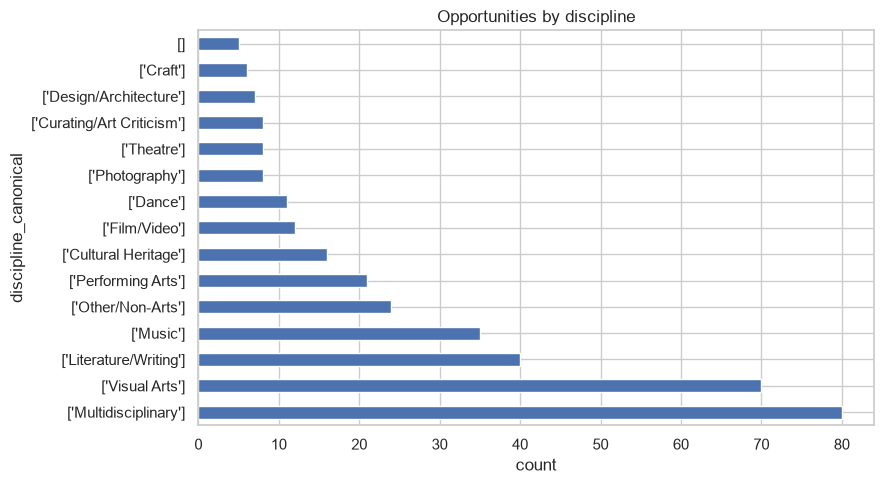

In [248]:
discipline_counts.head(15).plot(kind="barh", title="Opportunities by discipline")
plt.xlabel("count")
plt.tight_layout()
plt.show()

country_canonical
['Slovakia']                                                                                                                                                           59
['Belgium']                                                                                                                                                            53
[]                                                                                                                                                                     52
['Norway']                                                                                                                                                             43
['Germany']                                                                                                                                                            34
['Netherlands']                                                                                                                     

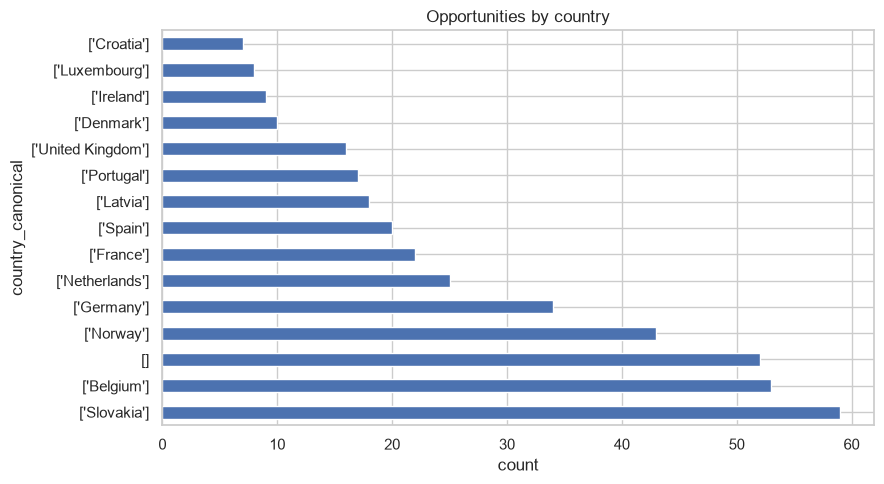

In [249]:
country_counts = exploration_df["country_canonical"].fillna("(not stated)").value_counts()
print(country_counts)
print(f"\n{exploration_df["country_canonical"].nunique()} distinct countries represented")
 
country_counts.head(15).plot(kind="barh", title="Opportunities by country")
plt.xlabel("count")
plt.tight_layout()
plt.show()

In [251]:
print("By source:")
print(exploration_df["source"].value_counts())

By source:
source
kunsten_be_flanders                    119
fpu_slovakia                            59
kulturdirektoratet_norway               41
mondriaan_fund                          18
vkkf_konkursu_grafiks                   18
dgartes_portugal                        15
kunststiftung_nrw                       13
matadero_madrid                         12
deutscher_uebersetzerfonds              12
arts_council_wales                      11
villa_arson                             10
cite_internationale_des_arts             9
kunst_dk_denmark                         9
creative_ireland                         9
nordic_culture_point                     8
ekkomed_greece                           8
european_cultural_foundation             7
focuna_luxembourg                        7
institut_francais_programs               7
min_kulture_croatia                      7
gasworks_london                          6
national_culture_fund_bulgaria           6
bmwkms_austria                      

Funded (funding field populated): 389 (81.2%)


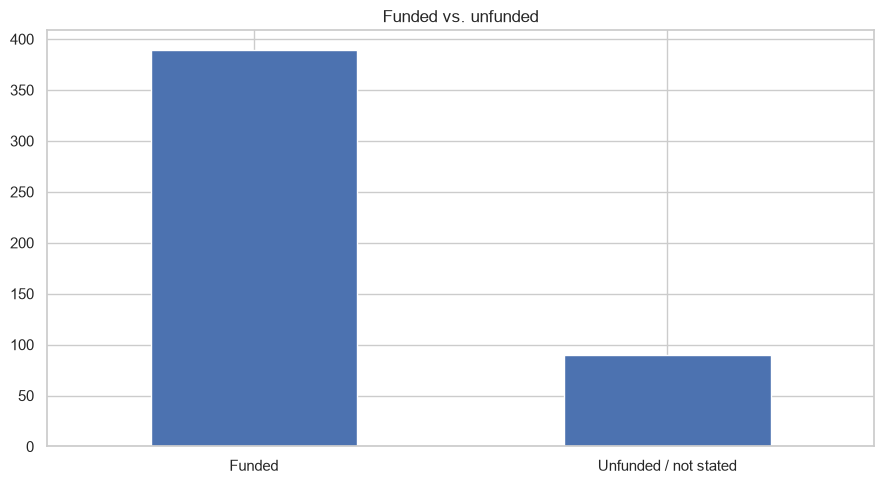

In [252]:
has_funding = exploration_df["funding"].notna() & (exploration_df["funding"].astype(str).str.strip() != "")
print(f"Funded (funding field populated): {has_funding.sum()} ({has_funding.mean():.1%})")

pd.Series({"Funded": has_funding.sum(), "Unfunded / not stated": (~has_funding).sum()}).plot(
    kind="bar", title="Funded vs. unfunded", rot=0
)
plt.tight_layout()
plt.show()

  RESIDENCE/NATIONALITY     present in  137 entries (28.6%)
  AGE                       present in  185 entries (38.6%)
  DISCIPLINE                present in   81 entries (16.9%)
  CAREER_STAGE              present in   96 entries (20.0%)
  EDUCATION                 present in   51 entries (10.6%)

  Entries with NO matched eligibility keyword at all: 141 (29.4%)
  -> this is your rough preview of how big the NONE class will be


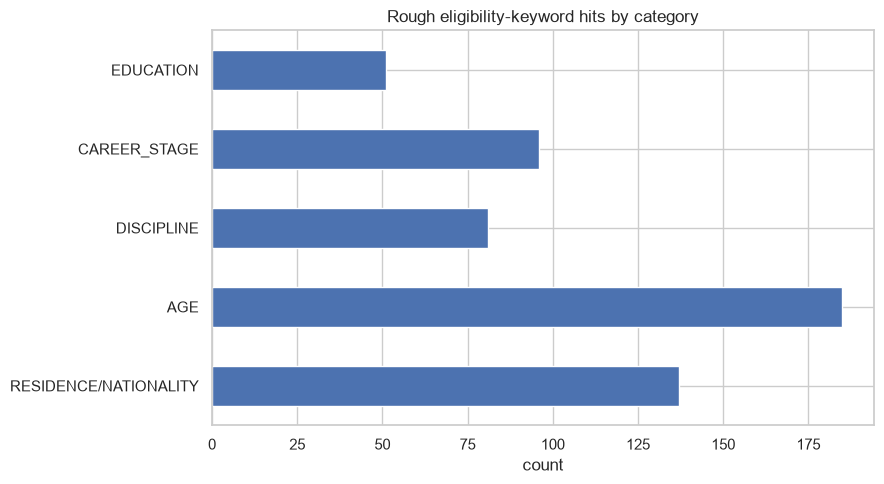

In [253]:
ELIGIBILITY_KEYWORDS = {
    "RESIDENCE/NATIONALITY": ["resident", "citizen", "nationality", "based in", "resid"],
    "AGE": ["age", "years old", "born after", "aged"],
    "DISCIPLINE": ["discipline", "medium", "practice in", "visual art", "sculpture", "painting"],
    "CAREER_STAGE": ["emerging", "early-career", "established", "professional artist"],
    "EDUCATION": ["degree", "enrolled", "student", "graduate"],
}
 
text_col = exploration_df["requirements_text_en"] if "requirements_text_en" in df.columns else df["requirements_text"]
text_lower = text_col.fillna("").str.lower()
 
keyword_hits = {}
for label, keywords in ELIGIBILITY_KEYWORDS.items():
    mask = text_lower.str.contains("|".join(keywords), regex=True)
    keyword_hits[label] = mask.sum()
    print(f"  {label:25s} present in {mask.sum():4d} entries ({mask.mean():.1%})")
 
any_keyword = text_lower.str.contains("|".join(sum(ELIGIBILITY_KEYWORDS.values(), [])), regex=True)
none_count = (~any_keyword).sum()
print(f"\n  Entries with NO matched eligibility keyword at all: {none_count} ({(~any_keyword).mean():.1%})")
print("  -> this is your rough preview of how big the NONE class will be")
 
pd.Series(keyword_hits).plot(kind="barh", title="Rough eligibility-keyword hits by category")
plt.xlabel("count")
plt.tight_layout()
plt.show()

In [255]:
exploration_df.columns

Index(['id', 'language', 'title_en', 'requirements_text_en', 'deadline_date',
       'source', 'organisation', 'description_en', 'country_canonical',
       'city_en', 'funding', 'funding_components', 'application_fee_has_fee',
       'discipline_canonical', 'opportunity_type_canonical',
       'career_stage_canonical'],
      dtype='str')

discipline_canonical  (other)  ['Cultural Heritage']  ['Film/Video']  \
country_canonical                                                      
(other)                    69                      5               6   
['Belgium']                21                      0               0   
['France']                 10                      0               1   
['Germany']                 5                      0               0   
['Netherlands']             9                      2               0   
['Norway']                  9                      4               0   
['Slovakia']               23                      5               0   
['Spain']                   9                      0               1   
[]                         26                      0               4   

discipline_canonical  ['Literature/Writing']  ['Multidisciplinary']  \
country_canonical                                                     
(other)                                    9                     

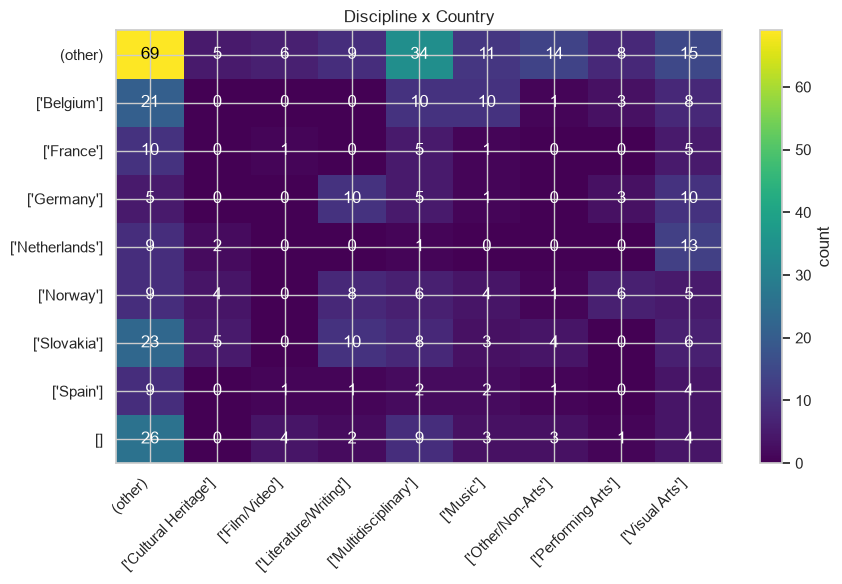

In [261]:
top_disciplines = exploration_df["discipline_canonical"].fillna("(not stated)").value_counts().head(8).index
top_countries = exploration_df["country_canonical"].fillna("(not stated)").value_counts().head(8).index
 
cross = pd.crosstab(
    exploration_df["country_canonical"].fillna("(not stated)").where(exploration_df["country_canonical"].isin(top_countries), "(other)"),
    exploration_df["discipline_canonical"].fillna("(not stated)").where(exploration_df["discipline_canonical"].isin(top_disciplines), "(other)"),
)
print(cross)
 
plt.figure(figsize=(9, 6))
plt.imshow(cross.values, aspect="auto", cmap="viridis")
plt.xticks(range(len(cross.columns)), cross.columns, rotation=45, ha="right")
plt.yticks(range(len(cross.index)), cross.index)
plt.colorbar(label="count")
plt.title("Discipline x Country")
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        plt.text(j, i, cross.values[i, j], ha="center", va="center",
                  color="white" if cross.values[i, j] < cross.values.max() / 2 else "black")
plt.tight_layout()
plt.show()


opportunity_type_canonical
['Grant/Funding']                          238
['Residency']                               81
['Open Call']                               65
['Other']                                   36
['Competition/Prize']                       29
['Workshop/Training']                        8
['Fellowship']                               6
['Commission']                               5
['Grant/Funding', 'Open Call']               3
['Grant/Funding', 'Residency']               1
['Open Call', 'Other']                       1
['Exhibition/Showcase']                      1
['Open Call', 'Residency']                   1
['Residency', 'Grant/Funding', 'Other']      1
['Grant/Funding', 'Fellowship']              1
['Exhibition/Showcase', 'Residency']         1
[]                                           1
Name: count, dtype: int64


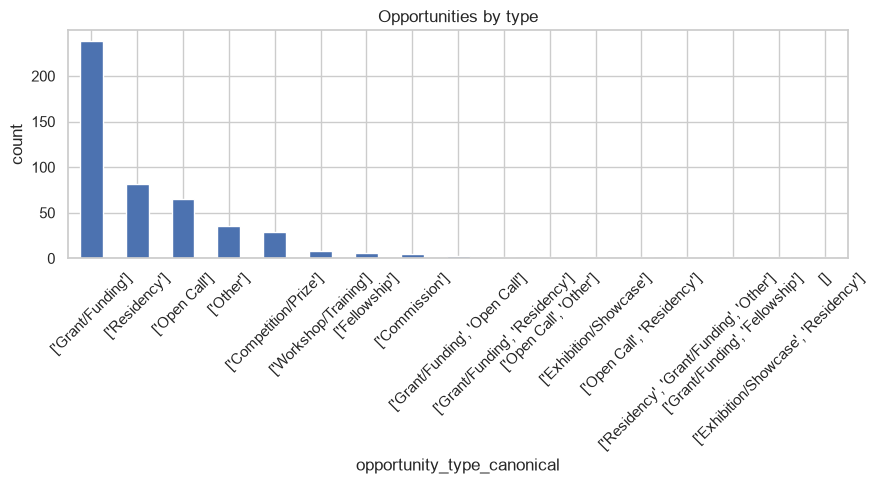

In [259]:
if "opportunity_type" in df.columns:
    type_counts = exploration_df["opportunity_type_canonical"].fillna("(not stated)").value_counts()
    print(type_counts)
 
    type_counts.plot(kind="bar", title="Opportunities by type", rot=45)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()
else:
    print("No `opportunity_type` column found.")